# Automated Forest Indicators for Graubünden

This notebbok use indicators from the national forest invetory canopy height in the canton are of Switzerland. 

The goal was to answer the question:
**How much of tree cover each municipality present and how tall are the forest in this areas?** 

**Indicator set per municipality:**
- Canopy cover is the area in the municipality with vegetation >=3m
- Forest area is showed in km² (km²)
- Mean of forest height is in meter (m)
- 90th percentile height (m), measures the upper canopy layer

**Data:**
- Vegetationshöhenmodell LFI 2025 (WSL/BAFU) with 1 meter resolution
- swissBOUDARIES3D, municipality boundaries (swisstopo)

**Output:** a GeoPackage with results and an interactive Folium map.

## 1. Setup the notebook

After creating the envirnonment then import the packages and paths needed for analysis. 

In [10]:
#all imports in one cell:

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import folium
import branca.colormap as cm

In [11]:
# --- Paths ---
DATA_RAW = Path("../data_raw")
OUTPUTS = Path("../outputs")
OUTPUTS.mkdir(exist_ok=True)

VHM_FILE = DATA_RAW / "vegmodell_inventar2025.tif"   # canopy height model (LFI 2025, 1 m)
GEM_FILE = DATA_RAW / "swissborders.gpkg"     # swissBOUNDARIES3D

# --- Settings ---
CANTON_NR = 18                                # Graubünden
MUNICIPALITIES_BFS = [3851, 3901, 3972, 3847, 3962]   # Davos, Chur, Seewis i.P., Val Müstair, Schiers
FOREST_THRESHOLD_M = 3                        # vegetation >= 3 m counts as tree canopy

## 2. Load the selected municipalities

The boundaries between municipalities are from swissBOUNDARIES3D - (the layer 'tlm_hoheitsgebiet').

Only 5 municipalities were selected for this analyses.
One way is to select them by is by 'name' or 'bfs_nummer'.
Names: Davos, Chur, Seewis i.P., Val Müstair and Schiers.

As the bfs_nummer also contain the row whit more detail infomation and are unique they work as ID.
For coding facilities the use of ID - digits- is better than name -letters- with ü and ä and spaces-. 

In [3]:
gem = gpd.read_file(GEM_FILE, layer="tlm_hoheitsgebiet")

sel = gem[(gem["kantonsnummer"] == CANTON_NR) & (gem["bfs_nummer"].isin(MUNICIPALITIES_BFS))]

print("CRS:", sel.crs)
print("Selected municipalities:", len(sel))
sel[["name", "bfs_nummer"]]

CRS: EPSG:2056
Selected municipalities: 5


,name,bfs_nummer
98,Davos,3851
852,Chur,3901
1068,Seewis im Prättigau,3972
1114,Val Müstair,3847
1880,Schiers,3962


**First visualization of the map, see if all the five municipalities are correct.:** correct sel if municipalities don't match

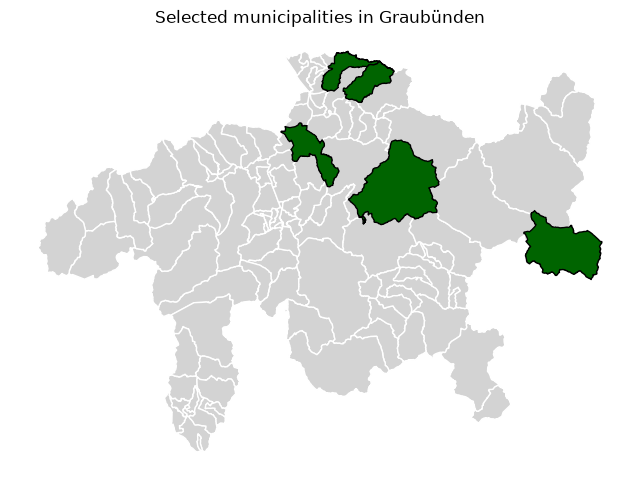

In [4]:
ax = gem[gem["kantonsnummer"] == CANTON_NR].plot(figsize=(8, 6), edgecolor="white", facecolor="lightgrey")
sel.plot(ax=ax, edgecolor="black", facecolor="darkgreen")
ax.set_title("Selected municipalities in Graubünden")
ax.set_axis_off()

## 3. Forest indicators per municipality

For each municipality the height model is clipped and only pixels inside the boudaries can be acessed.
With this clipping of only the area of interest the full Swiss raster (300 GB memory) is never completly load.

**Method:**
1. Pixels without data (nodata) are set to be NaN and ignored.
2. Every pixel with a height >= 3 m counts as tree canopy.
3. Calculation from pixels:
   -**Canopy cover**: municipality total area coverd by tree canopy
   -**Forest area**: canopy pixel x 1m² (in km²)
   -**Mean height**: the mean value of all canopy pixel
   -**90th percentile height**: describes the upper canopy layer
   

In [5]:
def forest_indicators(geometry, threshold=FOREST_THRESHOLD_M):
    """Calculate forest indicators for one municipality from the canopy height model.

    geometry  -- list of shapes (one municipality), in the raster's CRS (EPSG:2056)
    threshold -- minimum vegetation height (m) that counts as tree canopy
    """
    # Clip the raster to the municipality (reads only this area no all tiff)
    with rasterio.open(VHM_FILE) as src:
        nodata = src.nodata
        img, _ = mask(src, geometry, crop=True)

    # Set nodata pixels (outside the boundary) to NaN and automacaly ignore it
    h = img[0]
    h[h == nodata] = np.nan

    # Tree canopy mask
    valid = np.sum(~np.isnan(h))
    canopy = h >= threshold
    canopy_h = h[canopy]

    return {
        "canopy_cover_pct": round(float(np.sum(canopy) / valid * 100), 1),
        "forest_area_km2": round(float(np.sum(canopy) / 1_000_000), 1),
        "mean_height_m": round(float(np.mean(canopy_h)), 1),
        "p90_height_m": round(float(np.percentile(canopy_h, 90)), 1),
    }

## 4. Run the analysis
The following function get the selected municipality. The results is joined back to the municipality shapes using the BFS number, so they can be saved as geodata and shown on a map.

In [6]:
results = []

for _, row in sel.iterrows():
    print(f"Processing {row['name']} ...")
    r = forest_indicators([row.geometry])
    r["bfs_nummer"] = row["bfs_nummer"]
    results.append(r)

df = pd.DataFrame(results)

# Join the results to the municipality shapes
res = sel[["bfs_nummer", "name", "geometry"]].merge(df, on="bfs_nummer")
res = res.sort_values("canopy_cover_pct", ascending=False)

res.drop(columns="geometry")

Processing Davos ...
Processing Chur ...
Processing Seewis im Prättigau ...
Processing Val Müstair ...
Processing Schiers ...


,bfs_nummer,name,canopy_cover_pct,forest_area_km2,mean_height_m,p90_height_m
4,3962,Schiers,43.9,27.1,19.3,30.4
1,3901,Chur,42.4,34.7,16.8,27.6
2,3972,Seewis im Prättigau,27.8,13.8,15.6,27.6
3,3847,Val Müstair,20.0,39.6,15.1,26.7
0,3851,Davos,18.3,51.8,16.4,27.4


## 5. Save the results
- `forest_indicators_gr.gpkg`: results with municipality shapes, for QGIS/ArcGIS
- `forest_indicators_gr.csv`: results as a simple table, without shapes

In [13]:
res.to_file(OUTPUTS / "forest_indicators_gr.gpkg", layer="indicators", driver="GPKG")
res.drop(columns="geometry").to_csv(OUTPUTS / "forest_indicators_gr.csv", index=False)

print("Saved to:", OUTPUTS)

Saved to: ..\outputs


## 6. Interactive map
The results can be vizualised in an interactive Folium map with two layers that can be switched in the top right corner:
- **Canopy cover (%)**, with a tooltip showing all indicators
- **Mean forest height (m)**

Background: swisstopo grey national map. The shapes are converted from LV95 (EPSG:2056) to longitude/latitude (EPSG:4326), which Folium requires.

In [8]:
# Folium needs longitude/latitude defined by defaut
res_map = res.to_crs(epsg=4326)

# Background map and color scales
SWISSTOPO_GREY = "https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.pixelkarte-grau/default/current/3857/{z}/{x}/{y}.jpeg"
cmap_cover = cm.LinearColormap(["#f7fcf5", "#00441b"], vmin=0, vmax=50, caption="Canopy cover (%)")
cmap_height = cm.LinearColormap(["#fff7bc", "#993404"], vmin=10, vmax=25, caption="Mean forest height (m)")

# Map with swisstopo background
m = folium.Map(location=[46.8, 9.6], zoom_start=9, tiles=None)
folium.TileLayer(tiles=SWISSTOPO_GREY, attr="© swisstopo", name="swisstopo (grey)").add_to(m)

# Layer 1: canopy cover, with tooltip
folium.GeoJson(
    res_map,
    name="Canopy cover",
    style_function=lambda f: {
        "fillColor": cmap_cover(f["properties"]["canopy_cover_pct"]),
        "color": "black", "weight": 1, "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "canopy_cover_pct", "forest_area_km2", "mean_height_m", "p90_height_m"],
        aliases=["Municipality:", "Canopy cover (%):", "Forest area (km²):", "Mean height (m):", "90th percentile (m):"],
    ),
).add_to(m)

# Layer 2: mean forest height (off at start)
folium.GeoJson(
    res_map,
    name="Mean forest height",
    show=False,
    style_function=lambda f: {
        "fillColor": cmap_height(f["properties"]["mean_height_m"]),
        "color": "black", "weight": 1, "fillOpacity": 0.7,
    },
).add_to(m)

# Legends and layer menu
cmap_cover.add_to(m)
cmap_height.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m

## 7. Save the interactive map
The map can be saved as html in the outputs.

In [12]:
m.save(OUTPUTS / "forest_indicators_gr.html")
print("Saved to:", OUTPUTS)

Saved to: ..\outputs


## 8. Results and limitations

**Key results**
- Schiers and Chur have the highest canopy cover (over 40 %). Schiers also has the tallest forest (mean 19.3 m, 90th percentile 30.4 m).
- Davos and Val Müstair have the lowest canopy cover (about 20 %), mainly because large parts of these municipalities lie above the tree line. In absolute terms, Davos still has the largest forest area (51.8 km²).
- Canopy cover (share) and forest area (absolute) tell different stories, so both are shown.

**Limitations**
- **Canopy cover is not the official forest area.** Every 1 m pixel with vegetation ≥ 3 m counts. Gaps inside forests (roads, clearings) count as "no canopy", while single trees and hedges outside forests count as canopy. The official forest definition uses minimum area, width and crown cover.
- **The 3 m threshold is a choice.** It can be changed in the settings (`FOREST_THRESHOLD_M`) function.
- **Buildings** are already excluded in the LFI canopy height model (checked with spot samples in Chur).
- Only five municipalities were analysed as a pilot. The workflow can be applied to any municipality by changing `MUNICIPALITIES_BFS`.